# Experiment: Discrete Click Single-Trial Tracking Check

Objective:
- Run one discrete-mode trial and visually compare the latent reference trajectory `x_ref = model.x_traj` against the circuit readouts `x_E` and `x_B`.
- Use the requested single-trial parameter block: `lambda_right = 0.01`, `lambda_left = 0.005`, `c = 0.1`, `dx = 0.1`.

Success criteria:
- The notebook calibrates `c_{BE}(\theta)` once through the same `target_diffusion` path used elsewhere.
- The final figure makes it easy to judge whether `x_E` and `x_B` track the reference `x_ref` over the full trial.

Important note:
- The current discrete implementation interprets `lambda_click_L` and `lambda_click_R` as 1 ms Bernoulli rates. This notebook applies the requested numeric values directly on that 1 ms grid.
- The raw reference `x_ref` still jumps instantly when a click occurs, but the circuit-side discrete click drive is now spread over `dt_DDM` to keep `I_BE` closer to the alignment regime.


## Important

This notebook sets conservative CPU-thread environment variables for the JAX/BrainPy runtime.
Run it from a fresh kernel and execute from the top. If JAX was already imported earlier in the session, restart the kernel first.


In [48]:
from __future__ import annotations

import runpy
from pathlib import Path

_NOTEBOOK_SETUP = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    helper = candidate / "figures_code" / "notebook_setup.py"
    if helper.exists():
        _NOTEBOOK_SETUP = runpy.run_path(str(helper))
        break
if _NOTEBOOK_SETUP is None:
    raise RuntimeError("Could not locate figures_code/notebook_setup.py")

REPO_ROOT = _NOTEBOOK_SETUP["REPO_ROOT"]

import matplotlib.pyplot as plt
import numpy as np

from CANN_DDM_model_rate_based import CANN_DDM_model
from rate_model_core.default_params import build_stable_default_params

SEED = 17
DT_DDM = 5.0
DT_MODEL = 1.0
T_START = 20
DUR = 1500
X0 = 0.5
BOUNDARY = 1.0
THETA_MARGIN = 0.02
C_BE_SWEEP = np.array([0.0, 0.04], dtype=float)
MIN_ACCUMULATION_SAMPLES = 80
LAMBDA_RIGHT = 0.03
LAMBDA_LEFT = 0.01
NOISE_SCALE = 0.2
DELTA_CLICK_X = 0.05

np.random.seed(SEED)
REPO_ROOT


PosixPath('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model')

## Shared setup

The notebook follows the same calibration pattern as `figures_code/supp/v_drive_calibration.ipynb`, but uses only one discrete trial.

- `decision_mode = "discrete"`
- one shared call to `prepare_target_diffusion_mode()`
- raw `x_ref` remains jump-like on the 1 ms click grid
- click-driven `v_drift` is held over each `dt_DDM` window
- one trial with the requested click-rate, noise, and click-step settings


In [47]:
MODEL_STRIDE = int(round(float(DT_MODEL)))
if MODEL_STRIDE <= 0 or not np.isclose(float(DT_MODEL), float(MODEL_STRIDE)):
    raise ValueError("DT_MODEL must be a positive integer number of milliseconds for this notebook.")
T_START_IDX = int(round(float(T_START) / float(DT_MODEL)))
if not np.isclose(float(T_START), float(T_START_IDX) * float(DT_MODEL)):
    raise ValueError("T_START must align to the DT_MODEL sampling grid in this notebook.")


def build_discrete_params(*, seed: int = SEED, kappa: float | None = None) -> dict:
    params = build_stable_default_params()
    params["bump_pop"]["noise_scale_bump"] = 0.0
    params["edge_pop"]["noise_scale_edge"] = 0.0
    params["edge_pop"]["c_EB"] = 0.1

    c_be_params = {
        "mode": "target_diffusion",
        "theta_margin": THETA_MARGIN,
    }
    if kappa is not None:
        c_be_params["kappa"] = float(kappa)
    params["bump_pop"]["c_BE_params"] = c_be_params

    params["decision_space_params"]["decision_mode"] = "discrete"
    params["decision_space_params"]["t_start"] = T_START
    params["decision_space_params"]["dur"] = DUR
    params["decision_space_params"]["dt_DDM"] = DT_DDM
    params["decision_space_params"]["x0"] = float(X0)
    params["decision_space_params"]["boundary"] = float(BOUNDARY)
    params["decision_space_params"]["seed"] = int(seed)
    params["decision_space_params"]["drift_rate"] = 0.0
    params["decision_space_params"]["noise_scale"] = float(NOISE_SCALE)
    params["decision_space_params"]["lambda_click_R"] = float(LAMBDA_RIGHT)
    params["decision_space_params"]["lambda_click_L"] = float(LAMBDA_LEFT)
    params["decision_space_params"]["delta_click_x"] = float(DELTA_CLICK_X)
    return params


def prepare_shared_calibration(seed: int = SEED):
    model = CANN_DDM_model(CANN_params=build_discrete_params(seed=seed))
    calibration = model.prepare_target_diffusion_mode(
        c_be_sweep=C_BE_SWEEP,
        min_accumulation_samples=MIN_ACCUMULATION_SAMPLES,
    )
    return calibration


def run_trial(*, seed: int, kappa: float):
    model = CANN_DDM_model(CANN_params=build_discrete_params(seed=seed, kappa=kappa))
    runner = model.run_simulation(
        mon_vars=["x_E", "x_B", "theta_E", "theta_B", "v_drift", "v_noise", "v_drive", "hit_boundary", "r_E", "r_B"],
        progress_bar=False,
        dt=DT_MODEL,
        get_RT=False,
    )
    x_ref_full = np.asarray(model.x_traj, dtype=float)
    x_ref = x_ref_full[::MODEL_STRIDE]
    click_R = np.asarray(model.click_R_all, dtype=float)[::MODEL_STRIDE]
    click_L = np.asarray(model.click_L_all, dtype=float)[::MODEL_STRIDE]
    return {
        "seed": int(seed),
        "r_E": np.asarray(runner.mon.r_E),
        "r_B": np.asarray(runner.mon.r_B),
        "times": np.arange(len(x_ref), dtype=float) * DT_MODEL,
        "x_ref": x_ref,
        "x_E": np.asarray(runner.mon.x_E).reshape(-1),
        "x_B": np.asarray(runner.mon.x_B).reshape(-1),
        "theta_E": np.asarray(runner.mon.theta_E).reshape(-1),
        "theta_B": np.asarray(runner.mon.theta_B).reshape(-1),
        "v_drift": np.asarray(runner.mon.v_drift).reshape(-1),
        "v_noise": np.asarray(runner.mon.v_noise).reshape(-1),
        "v_drive": np.asarray(runner.mon.v_drive).reshape(-1),
        "hit_boundary": np.asarray(runner.mon.hit_boundary).reshape(-1),
        "click_R": click_R,
        "click_L": click_L,
        "expected_net_clicks": float((LAMBDA_RIGHT - LAMBDA_LEFT) * max(DUR - T_START, 0)),
        "expected_x_shift": float((LAMBDA_RIGHT - LAMBDA_LEFT) * max(DUR - T_START, 0) * DELTA_CLICK_X),
    }


def summarize_trial(trial: dict, calibration: dict) -> dict:
    x_ref = np.asarray(trial["x_ref"], dtype=float)
    x_E = np.asarray(trial["x_E"], dtype=float)
    x_B = np.asarray(trial["x_B"], dtype=float)
    return {
        "seed": int(trial["seed"]),
        "lambda_right": float(LAMBDA_RIGHT),
        "lambda_left": float(LAMBDA_LEFT),
        "noise_scale": float(NOISE_SCALE),
        "delta_click_x": float(DELTA_CLICK_X),
        "right_click_count": int(np.sum(trial["click_R"])),
        "left_click_count": int(np.sum(trial["click_L"])),
        "expected_net_clicks": float(trial["expected_net_clicks"]),
        "expected_x_shift": float(trial["expected_x_shift"]),
        "x_ref_final": float(x_ref[-1]),
        "x_E_final": float(x_E[-1]),
        "x_B_final": float(x_B[-1]),
        "x_E_rmse_vs_ref": float(np.sqrt(np.mean((x_E - x_ref) ** 2))),
        "x_B_rmse_vs_ref": float(np.sqrt(np.mean((x_B - x_ref) ** 2))),
        "hit_boundary_any": bool(np.any(trial["hit_boundary"])),
        "kappa": float(calibration["kappa"]),
        "certificate_passed": bool(calibration["certificate_passed"]),
    }


def plot_trial(trial: dict):
    times = np.asarray(trial["times"], dtype=float)

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(11, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.0, 1.2]},
    )

    axes[0].plot(times, trial["x_ref"], color="#111827", linewidth=2.2, label=r"$x_{ref}$")
    axes[0].plot(times, trial["x_E"], color="#0f766e", linewidth=1.8, label=r"$x_E$")
    axes[0].plot(times, trial["x_B"], color="#b45309", linewidth=1.8, label=r"$x_B$")
    axes[0].axvline(T_START, color="#9ca3af", linestyle="--", linewidth=1.0)
    axes[0].set_ylabel("x")
    axes[0].set_title("Discrete single-trial tracking against the latent reference trajectory")
    axes[0].legend(loc="best")
    axes[0].grid(alpha=0.25)

    axes[1].step(times, trial["click_R"], where="post", color="#2563eb", linewidth=1.5, label="right clicks")
    axes[1].step(times, -trial["click_L"], where="post", color="#dc2626", linewidth=1.5, label="left clicks")
    axes[1].axhline(0.0, color="#6b7280", linewidth=1.0)
    axes[1].set_ylabel("clicks")
    axes[1].legend(loc="best")
    axes[1].grid(alpha=0.25)

    axes[2].plot(times, trial["v_drift"], color="#1d4ed8", linewidth=1.5, label=r"$v_{drift}$")
    axes[2].plot(times, trial["v_noise"], color="#7c3aed", linewidth=1.3, label=r"$v_{noise}$")
    axes[2].plot(times, trial["v_drive"], color="#be123c", linewidth=1.5, linestyle="--", label=r"$v_{drive}$")
    axes[2].axhline(0.0, color="#6b7280", linewidth=1.0)
    axes[2].set_ylabel("drive")
    axes[2].set_xlabel("time (ms)")
    axes[2].legend(loc="best")
    axes[2].grid(alpha=0.25)

    fig.tight_layout()
    return fig


In [19]:
calibration = prepare_shared_calibration()
calibration_summary = {
    "kappa": float(calibration["kappa"]),
    "c_be_theta_max": float(calibration["c_be_theta_max"]),
    "certificate_passed": bool(calibration["certificate_passed"]),
}
calibration_summary


/scratch/ipykernel_1209434/144919843.py:40: UserWarning: target_diffusion calibration did not pass the alignment/kappa consistency certificate; continuing anyway.
  calibration = model.prepare_target_diffusion_mode(


{'kappa': 0.015503165162608376,
 'c_be_theta_max': 0.5280059638820865,
 'certificate_passed': False}

## Single trial

Run exactly one trial with the requested settings and compare `x_ref`, `x_E`, and `x_B` directly.


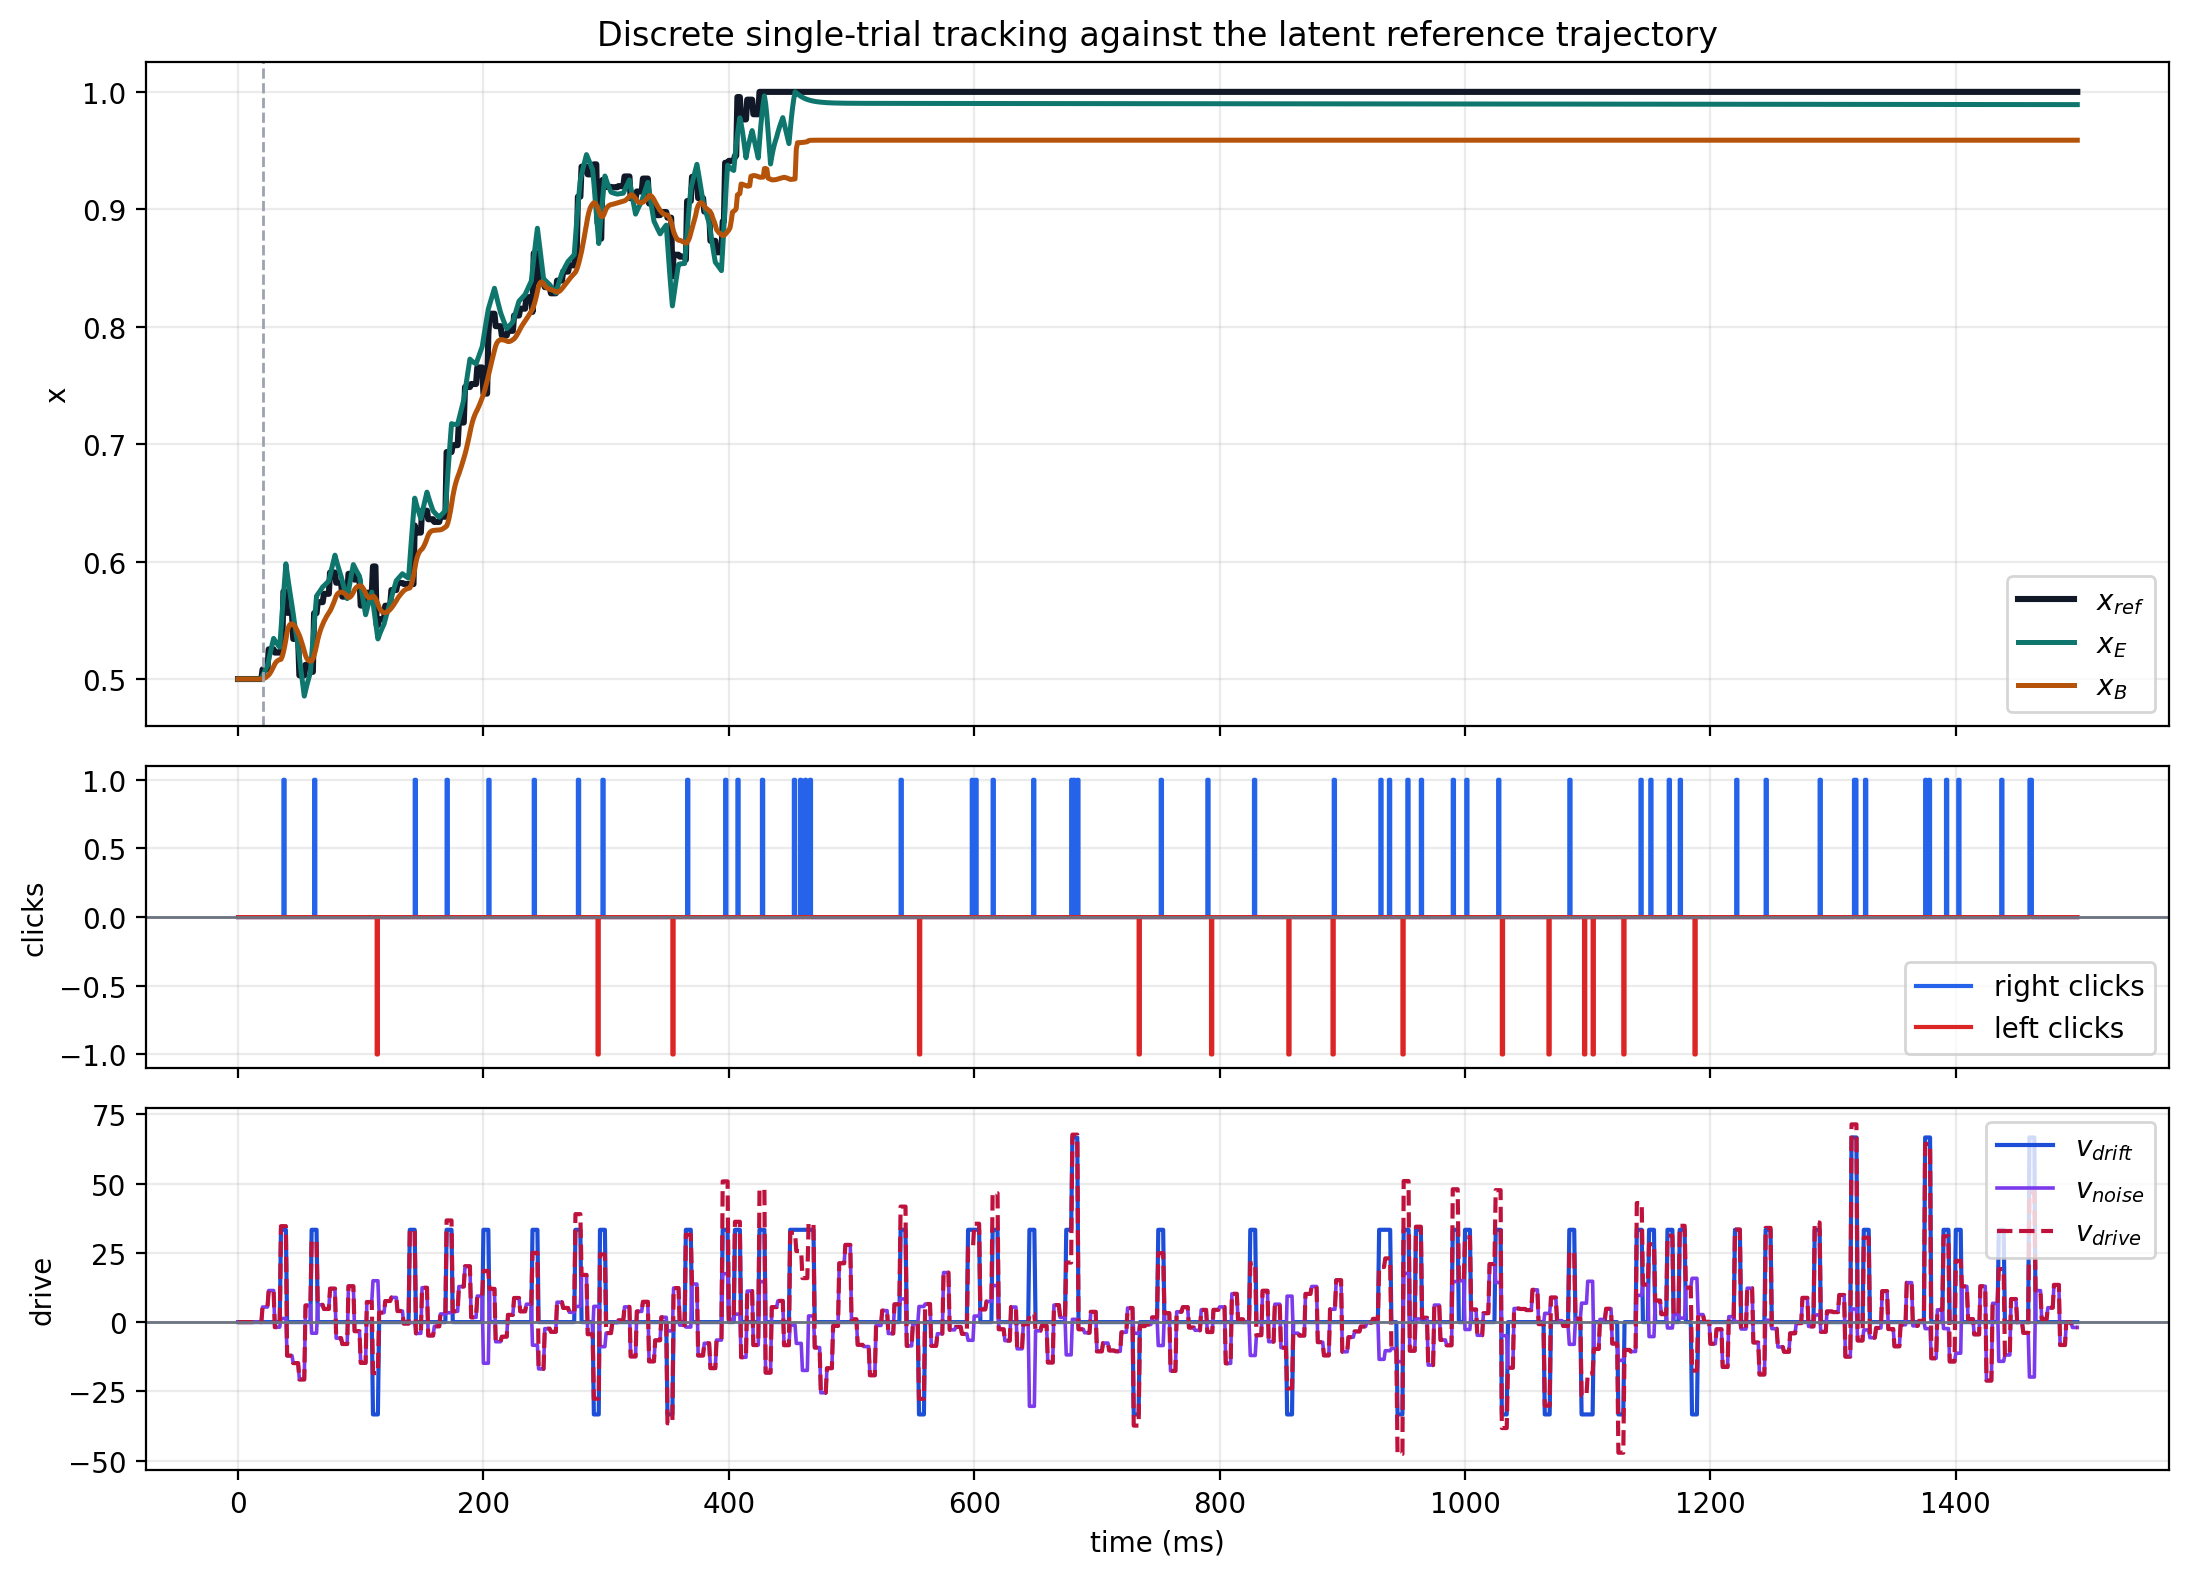

In [49]:
SEED = 321
trial = run_trial(seed=SEED, kappa=float(calibration["kappa"]))
plot_trial(trial)
trial_summary = summarize_trial(trial, calibration)



## What to inspect

- Whether `x_E` stays close to `x_ref` over the whole trial, not just at the endpoint.
- Whether `x_B` tracks the same latent trajectory or lags/biases relative to `x_E`.
- Whether visible tracking errors line up with bursts in the discrete click stream or with the Gaussian `v_noise` component.
